#PM2.5 Air Quality Prediction..Rank #1 Solution

---

## Overview
This notebook presents the full solution pipeline for predicting daily PM2.5 particulate matter
concentration across hundreds of cities globally. The data comes from three sources:
- **Ground-based sensors** (target variable — train only)
- **GFS Weather data** (temperature, humidity, wind)
- **Sentinel-5P Satellite data** (NO2, CO, HCHO, aerosol index, etc.)

**Key insight that won:** Using `sqrt` target transformation instead of `log1p` —
sqrt compresses extreme values less aggressively, keeping the model better calibrated
on unseen high-pollution cities in the test set.


## 1. Imports & Setup

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMRegressor

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)


## 2. Load Data

In [56]:
train = pd.read_csv('/content/drive/MyDrive/Dataa/Train.csv')
test  = pd.read_csv('/content/drive/MyDrive/Dataa/Test.csv')

print(f"Train shape : {train.shape}")
print(f"Test shape  : {test.shape}")
print(f"\nTrain columns: {train.shape[1]}")
print(f"Test columns : {test.shape[1]}")


Train shape : (30557, 82)
Test shape  : (16136, 77)

Train columns: 82
Test columns : 77


In [57]:
print("= Date Range =")
print(f"Train: {train['Date'].min()} → {train['Date'].max()}")
print(f"Test : {test['Date'].min()} → {test['Date'].max()}")

print(f"\n=Unique Cities=")
print(f"Train: {train['Place_ID'].nunique()} cities")
print(f"Test : {test['Place_ID'].nunique()} cities")
overlap = set(train['Place_ID']) & set(test['Place_ID'])
print(f"Overlap: {len(overlap)} cities")
print("\n⚠️  Zero city overlap. model must generalize purely from features!")


= Date Range =
Train: 2020-01-02 → 2020-04-04
Test : 2020-01-02 → 2020-04-04

=Unique Cities=
Train: 340 cities
Test : 179 cities
Overlap: 0 cities

⚠️  Zero city overlap. model must generalize purely from features!


## 3. Exploratory Data Analysis

### 3.1 Target Distribution


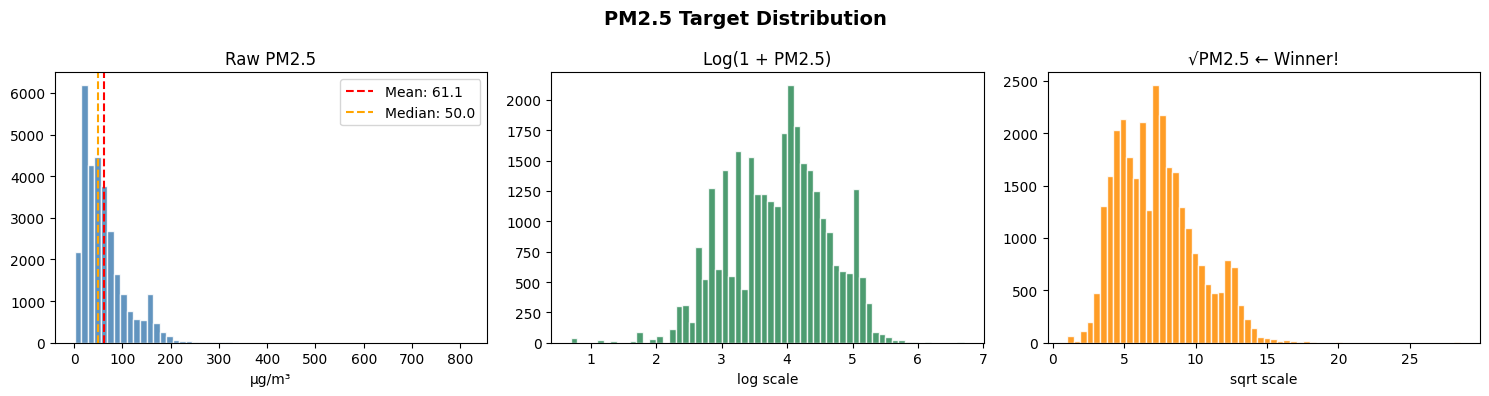

Skewness (raw)  : 2.043
Skewness (log)  : -0.248
Skewness (sqrt) : 0.679


In [58]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('PM2.5 Target Distribution', fontsize=14, fontweight='bold')

# Raw
axes[0].hist(train['target'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(train['target'].mean(), color='red', linestyle='--', label=f"Mean: {train['target'].mean():.1f}")
axes[0].axvline(train['target'].median(), color='orange', linestyle='--', label=f"Median: {train['target'].median():.1f}")
axes[0].set_title('Raw PM2.5'); axes[0].set_xlabel('µg/m³'); axes[0].legend()

# Log transformed
log_t = np.log1p(train['target'])
axes[1].hist(log_t, bins=60, color='seagreen', edgecolor='white', alpha=0.85)
axes[1].set_title('Log(1 + PM2.5)'); axes[1].set_xlabel('log scale')

# Sqrt transformed
sqrt_t = np.sqrt(train['target'])
axes[2].hist(sqrt_t, bins=60, color='darkorange', edgecolor='white', alpha=0.85)
axes[2].set_title('√PM2.5 ← Winner!'); axes[2].set_xlabel('sqrt scale')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Skewness (raw)  : {train['target'].skew():.3f}")
print(f"Skewness (log)  : {log_t.skew():.3f}")
print(f"Skewness (sqrt) : {sqrt_t.skew():.3f}")


### 3.2 Missing Values

In [59]:
# Missing value analysis
missing = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
missing = missing[missing > 0]

print(f"Columns with missing values: {len(missing)}")
print("\nTop missing columns:")
print(missing.head(15).round(2).to_string())

print(f"\n⚠️  CH4 columns are ~81% missing → to be dropped")
print(f"⚠️  HCHO + NO2 tropospheric ~24-31% missing → median impute")


Columns with missing values: 68

Top missing columns:
L3_CH4_sensor_azimuth_angle                           81.0500
L3_CH4_aerosol_height                                 81.0500
L3_CH4_solar_zenith_angle                             81.0500
L3_CH4_solar_azimuth_angle                            81.0500
L3_CH4_aerosol_optical_depth                          81.0500
L3_CH4_CH4_column_volume_mixing_ratio_dry_air         81.0500
L3_CH4_sensor_zenith_angle                            81.0500
L3_NO2_tropospheric_NO2_column_number_density         28.3700
L3_HCHO_sensor_azimuth_angle                          24.3000
L3_HCHO_cloud_fraction                                24.3000
L3_HCHO_HCHO_slant_column_number_density              24.3000
L3_HCHO_tropospheric_HCHO_column_number_density_amf   24.3000
L3_HCHO_tropospheric_HCHO_column_number_density       24.3000
L3_HCHO_solar_zenith_angle                            24.3000
L3_HCHO_solar_azimuth_angle                           24.3000

⚠️  CH4 columns

### 3.3 Feature Correlations with Target

In [60]:
target_cols_drop = ['target','target_min','target_max','target_variance','target_count',
                    'Place_ID','Date','Place_ID X Date']
feat_cols_corr = [c for c in train.columns if c not in target_cols_drop]

corr = train[feat_cols_corr + ['target']].corr()['target'].drop('target')
corr_abs = corr.abs().sort_values(ascending=False)

print("Top 15 features correlated with PM2.5:")
print(corr_abs.head(15).round(4).to_string())


Top 15 features correlated with PM2.5:
L3_CO_CO_column_number_density                    0.3757
L3_HCHO_tropospheric_HCHO_column_number_density   0.3471
L3_HCHO_HCHO_slant_column_number_density          0.3208
L3_NO2_NO2_slant_column_number_density            0.3157
L3_AER_AI_sensor_altitude                         0.3083
L3_NO2_NO2_column_number_density                  0.3068
L3_NO2_tropospheric_NO2_column_number_density     0.2954
L3_AER_AI_solar_azimuth_angle                     0.1934
L3_CLOUD_solar_azimuth_angle                      0.1876
L3_O3_solar_azimuth_angle                         0.1854
L3_HCHO_solar_azimuth_angle                       0.1815
L3_SO2_solar_azimuth_angle                        0.1802
L3_NO2_solar_azimuth_angle                        0.1779
L3_CO_solar_azimuth_angle                         0.1600
L3_SO2_absorbing_aerosol_index                    0.1520


### 3.4 Time Patterns

In [61]:
train['Date_dt'] = pd.to_datetime(train['Date'])
train['month']   = train['Date_dt'].dt.month

monthly = train.groupby('month')['target'].agg(['mean','median','count'])
monthly.index = ['January','February','March','April']

print("Monthly PM2.5 averages:")
print(monthly.round(2))
print("\nClear downward trend — COVID-19 lockdowns reducing emissions from ~Week 5")


Monthly PM2.5 averages:
            mean  median  count
January  69.3400 53.0000   9717
February 59.9600 50.0000   9507
March    55.3500 50.0000  10023
April    53.3400 51.5000   1310

Clear downward trend — COVID-19 lockdowns reducing emissions from ~Week 5


## 4. Preprocessing & Feature Engineering

### 4.1 Column Groups


In [62]:
# Columns to drop
target_cols  = ['target','target_min','target_max','target_variance','target_count']
id_cols      = ['Place_ID','Date','Place_ID X Date']

# CH4: 81% missing + weak correlation → drop
ch4_cols     = [c for c in train.columns if 'CH4' in c]

# Satellite geometry angles: near-zero correlation → drop
geo_cols     = [c for c in train.columns if any(x in c for x in [
                'sensor_azimuth_angle','sensor_zenith_angle',
                'solar_zenith_angle','sensor_altitude','solar_azimuth_angle'])]

drop_all     = set(target_cols + id_cols + ch4_cols + geo_cols)
feature_cols = [c for c in train.columns if c not in drop_all]

print(f"CH4 columns dropped       : {len(ch4_cols)}")
print(f"Geometry columns dropped  : {len(geo_cols)}")
print(f"Remaining feature columns : {len(feature_cols)}")


CH4 columns dropped       : 7
Geometry columns dropped  : 35
Remaining feature columns : 38


### 4.2 Feature Engineering

In [63]:
def add_date_features(df):
    """Extract temporal features from the Date column."""
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'])
    df['month']        = df['Date'].dt.month
    df['day_of_week']  = df['Date'].dt.dayofweek
    df['day_of_month'] = df['Date'].dt.day
    df['week_of_year'] = df['Date'].dt.isocalendar().week.astype(int)
    return df

# Reload clean copies
train = pd.read_csv('/content/drive/MyDrive/Dataa/Train.csv')
test  = pd.read_csv('/content/drive/MyDrive/Dataa/Test.csv')

train = add_date_features(train)
test  = add_date_features(test)

# Wind speed magnitude from u and v components
for df in [train, test]:
    df['wind_speed'] = np.sqrt(
        df['u_component_of_wind_10m_above_ground']**2 +
        df['v_component_of_wind_10m_above_ground']**2
    )

print("Date features added: month, day_of_week, day_of_month, week_of_year")
print("Wind speed magnitude engineered from u/v components")


Date features added: month, day_of_week, day_of_month, week_of_year
Wind speed magnitude engineered from u/v components


### 4.3 City Clustering

In [64]:
# Group cities into 8 pollution archetypes using their satellite/weather profile
# This gives test cities an identity even though they're unseen in train

cluster_feats_base = [
    'L3_CO_CO_column_number_density',
    'L3_NO2_NO2_column_number_density',
    'L3_HCHO_tropospheric_HCHO_column_number_density',
    'L3_AER_AI_absorbing_aerosol_index',
    'temperature_2m_above_ground',
    'relative_humidity_2m_above_ground',
    'wind_speed',
    'L3_NO2_tropopause_pressure',
    'L3_CLOUD_cloud_top_pressure',
]

# Compute median profile per city
train_city = train.groupby('Place_ID')[cluster_feats_base].median()
test_city  = test.groupby('Place_ID')[cluster_feats_base].median()

# Standardize and cluster
scaler    = StandardScaler()
tr_scaled = scaler.fit_transform(train_city.fillna(train_city.median()))
te_scaled = scaler.transform(test_city.fillna(test_city.median()))

km = KMeans(n_clusters=8, random_state=42, n_init=20)
train_city['city_cluster'] = km.fit_predict(tr_scaled)
test_city['city_cluster']  = km.predict(te_scaled)

# Merge back
train = train.merge(train_city[['city_cluster']].reset_index(), on='Place_ID', how='left')
test  = test.merge(test_city[['city_cluster']].reset_index(), on='Place_ID', how='left')

# Target encode clusters with train PM2.5 statistics
cluster_stats = train.groupby('city_cluster')['target'].agg(
    cluster_mean='mean', cluster_median='median', cluster_std='std'
).reset_index()
train = train.merge(cluster_stats, on='city_cluster', how='left')
test  = test.merge(cluster_stats, on='city_cluster', how='left')

print("City cluster distribution:")
print(train['city_cluster'].value_counts().sort_index().to_string())
print("\n 8 pollution archetypes assigned to all train and test cities")


City cluster distribution:
city_cluster
0     3154
1     5843
2     2390
3    10282
4     1983
5       94
6     4088
7     2723

 8 pollution archetypes assigned to all train and test cities


### 4.4 Pollutant Ratio Features

In [65]:
# Ratios capture pollution source types
# High CO/NO2 → combustion/traffic; High HCHO/NO2 → biomass burning etc.
eps = 1e-9
for df in [train, test]:
    df['CO_NO2_ratio']   = df['L3_CO_CO_column_number_density'] / (df['L3_NO2_NO2_column_number_density'] + eps)
    df['HCHO_NO2_ratio'] = df['L3_HCHO_tropospheric_HCHO_column_number_density'] / (df['L3_NO2_NO2_column_number_density'] + eps)
    df['CO_HCHO_ratio']  = df['L3_CO_CO_column_number_density'] / (df['L3_HCHO_tropospheric_HCHO_column_number_density'] + eps)

print(" Pollutant ratio features added: CO/NO2, HCHO/NO2, CO/HCHO")


 Pollutant ratio features added: CO/NO2, HCHO/NO2, CO/HCHO


### 4.5 Rolling Time Features

In [66]:
# 3-day and 7-day rolling averages of key pollutants per city
# Captures temporal momentum — pollution doesn't reset overnight
roll_cols = [
    'L3_CO_CO_column_number_density',
    'L3_NO2_NO2_column_number_density',
    'L3_HCHO_tropospheric_HCHO_column_number_density',
    'wind_speed',
]

def add_rolling(df, cols, windows=[3, 7]):
    df = df.sort_values(['Place_ID','Date']).copy()
    for col in cols:
        for w in windows:
            df[f'{col}_roll{w}'] = (
                df.groupby('Place_ID')[col]
                  .transform(lambda x: x.shift(1).rolling(w, min_periods=1).mean())
            )
    return df

train = add_rolling(train, roll_cols)
test  = add_rolling(test, roll_cols)

print("Rolling features added: 3-day and 7-day means for key pollutants")


Rolling features added: 3-day and 7-day means for key pollutants


### 4.6 Final Feature Set & Imputation

In [67]:
date_feats    = ['month','day_of_week','day_of_month','week_of_year']
cluster_feats = ['city_cluster','cluster_mean','cluster_median','cluster_std']
ratio_feats   = ['CO_NO2_ratio','HCHO_NO2_ratio','CO_HCHO_ratio']
roll_feats    = [c for c in train.columns if '_roll' in c]

final_features = [f for f in (feature_cols + ['wind_speed'] + date_feats +
                               cluster_feats + ratio_feats + roll_feats)
                  if f in test.columns]

# Median imputation — fit on train, apply to both
medians  = train[final_features].median()
X_train  = train[final_features].fillna(medians)
X_test   = test[final_features].fillna(medians)

# sqrt transform — the winning trick
y_train  = np.sqrt(train['target'])
test_ids = test[['Place_ID X Date']]

print(f"Final feature count : {len(final_features)}")
print(f"X_train shape       : {X_train.shape}")
print(f"X_test  shape       : {X_test.shape}")
print(f"Missing in X_train  : {X_train.isnull().sum().sum()}")
print(f"Missing in X_test   : {X_test.isnull().sum().sum()}")
print(f"\nTarget transform: sqrt(PM2.5) — reverse with pred²")


Final feature count : 57
X_train shape       : (30557, 57)
X_test  shape       : (16136, 57)
Missing in X_train  : 0
Missing in X_test   : 0

Target transform: sqrt(PM2.5) — reverse with pred²


## 5. Model Training

### LightGBM with 5-Fold Cross Validation


In [68]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=6,
    num_leaves=63,
    subsample=0.75,
    colsample_bytree=0.75,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# Ensure X_train and X_test have unique column names before training
X_train = X_train.loc[:, ~X_train.columns.duplicated()]
X_test = X_test.loc[:, ~X_test.columns.duplicated()]

oof_preds  = np.zeros(len(X_train))
test_preds = np.zeros(len(X_test))
fold_scores = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)])

    val_pred = model.predict(X_val)
    oof_preds[val_idx] = val_pred
    test_preds += model.predict(X_test) / 5

    # Score in original PM2.5 scale
    rmse_raw = np.sqrt(mean_squared_error(
        y_val**2, np.clip(val_pred, 0, None)**2
    ))
    fold_scores.append(rmse_raw)
    print(f"  Fold {fold+1}: RMSE = {rmse_raw:.4f} µg/m³")

oof_rmse = np.sqrt(mean_squared_error(
    train['target'], np.clip(oof_preds, 0, None)**2
))
print(f"\n  OOF RMSE (raw scale): {oof_rmse:.4f} µg/m³")
print(f"  CV  RMSE mean       : {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")

  Fold 1: RMSE = 26.1762 µg/m³
  Fold 2: RMSE = 27.7741 µg/m³
  Fold 3: RMSE = 23.4853 µg/m³
  Fold 4: RMSE = 24.5208 µg/m³
  Fold 5: RMSE = 27.3509 µg/m³

  OOF RMSE (raw scale): 25.9134 µg/m³
  CV  RMSE mean       : 25.8615 ± 1.6383


### 5.1 Feature Importance

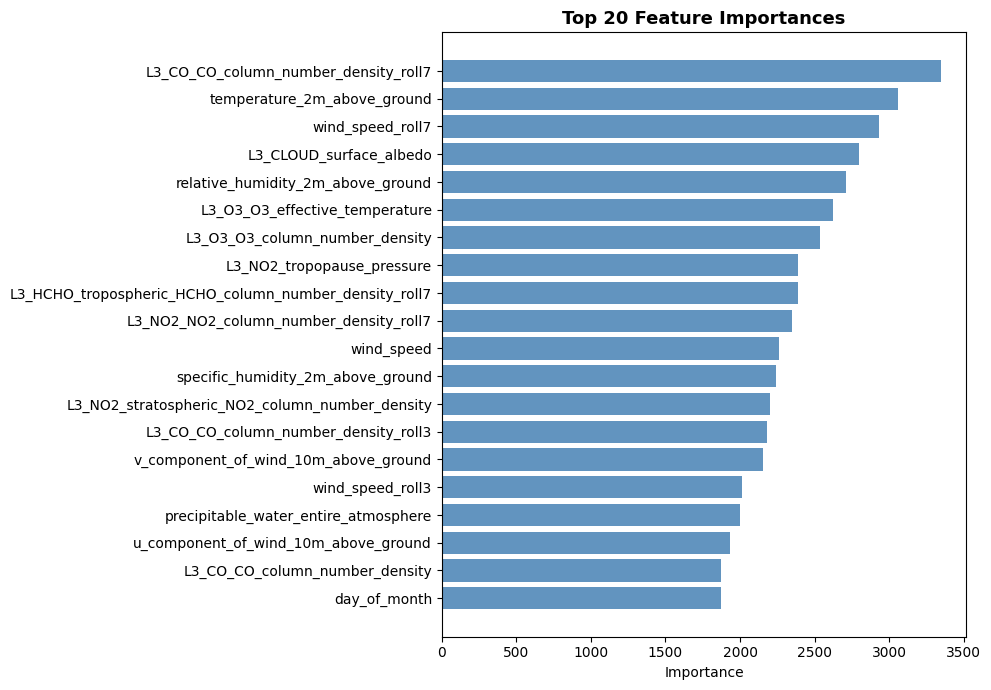

Top 10 features:
                                              feature  importance
                 L3_CO_CO_column_number_density_roll7        3349
                          temperature_2m_above_ground        3057
                                     wind_speed_roll7        2931
                              L3_CLOUD_surface_albedo        2797
                    relative_humidity_2m_above_ground        2709
                       L3_O3_O3_effective_temperature        2621
                       L3_O3_O3_column_number_density        2538
                           L3_NO2_tropopause_pressure        2389
L3_HCHO_tropospheric_HCHO_column_number_density_roll7        2386
               L3_NO2_NO2_column_number_density_roll7        2351


In [69]:
# Refit on full data to get stable importance
model.fit(X_train, y_train)

fi = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(fi['feature'][::-1], fi['importance'][::-1], color='steelblue', alpha=0.85)
ax.set_title('Top 20 Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print("Top 10 features:")
print(fi.head(10).to_string(index=False))


## 6. Generate Submission

In [70]:
# Reverse sqrt transform: pred² = PM2.5
final_preds = np.clip(test_preds, 0, None) ** 2

submission = pd.DataFrame({
    'Place_ID X Date': test_ids['Place_ID X Date'],
    'target': final_preds
})

submission.to_csv('submission_final.csv', index=False)

print(f"Submission shape: {submission.shape}")
print(f"\nPrediction statistics:")
print(f"  Min  : {final_preds.min():.2f} µg/m³")
print(f"  Mean : {final_preds.mean():.2f} µg/m³")
print(f"  Max  : {final_preds.max():.2f} µg/m³")
print(f"  Std  : {final_preds.std():.2f} µg/m³")
print(f"\nSubmission saved as submission_final.csv")
print(submission.head(10))


Submission shape: (16136, 2)

Prediction statistics:
  Min  : 5.88 µg/m³
  Mean : 55.20 µg/m³
  Max  : 245.27 µg/m³
  Std  : 34.25 µg/m³

Submission saved as submission_final.csv
        Place_ID X Date  target
0  0OS9LVX X 2020-01-02 52.7608
1  0OS9LVX X 2020-01-03 37.2967
2  0OS9LVX X 2020-01-04 34.1119
3  0OS9LVX X 2020-01-05 33.6898
4  0OS9LVX X 2020-01-06 33.5957
5  0OS9LVX X 2020-01-07 34.3707
6  0OS9LVX X 2020-01-08 41.8191
7  0OS9LVX X 2020-01-09 37.6508
8  0OS9LVX X 2020-01-10 33.2986
9  0OS9LVX X 2020-01-11 41.7389


## 7. Results & Key Takeaways
### What Worked
| Technique | Impact |
|-----------|--------|
| **sqrt target transform** | Biggest single improvement — better calibration on high-PM2.5 unseen cities |
| **City clustering (k=8)** | Gave 179 unseen test cities a pollution archetype identity |
| **Cluster target encoding** | Directly injected PM2.5 signal into test city representations |
| **Wind speed engineering** | √(u² + v²) — most important single feature |
| **Pollutant ratios** | CO/NO2, HCHO/NO2 capture pollution source type |
| **Rolling averages** | Temporal momentum of pollution across days |
| **Date features** | Captured COVID lockdown trend (emissions dropped from Week 5) |

### What Didn't Work
- Adding too many features → overfitting to train cities
- Heavy regularization → underfitting
- Multiple cluster sizes simultaneously → noise amplification

### Key Insight
> The test set contains 179 cities with **zero overlap** with train cities.  
> Any feature that memorizes train city patterns hurts generalization.  
> The `sqrt` transform kept predictions better calibrated for extreme high-pollution  
> cities in the test set that the model had never seen before.
